In [29]:
import torch
import os
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim

In [30]:
root = os.path.dirname(os.path.abspath('main.ipynb'))
dataPth = os.path.join(root, 'data')
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=dataPth, transform=transform)
full_dataset.classes

['cloudy',
 'foggy',
 'lightning',
 'rainbow',
 'rainy',
 'rime',
 'sandstorm',
 'sunrise']

In [31]:
train_dataset_len = int(0.8 * len(full_dataset))
test_dataset_len = len(full_dataset) - train_dataset_len

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_dataset_len, test_dataset_len]
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [32]:
images, labels = next(iter(train_loader))
images

tensor([[[[-1.9124, -1.9295, -1.9295,  ..., -1.8953, -1.8953, -1.8782],
          [-1.9809, -1.9980, -1.9980,  ..., -1.9638, -1.9467, -1.9295],
          [-1.9809, -2.0152, -1.9980,  ..., -1.9638, -1.9467, -1.9124],
          ...,
          [-1.8610, -1.8610, -1.8610,  ..., -1.8953, -1.8782, -1.8439],
          [-1.8439, -1.8610, -1.8610,  ..., -1.8610, -1.8610, -1.8439],
          [-1.7925, -1.8097, -1.8268,  ..., -1.8097, -1.7925, -1.7925]],

         [[-1.4930, -1.5105, -1.4755,  ..., -1.7031, -1.7206, -1.6856],
          [-1.5105, -1.5105, -1.5105,  ..., -1.7381, -1.7731, -1.7556],
          [-1.5105, -1.4930, -1.4580,  ..., -1.7556, -1.7556, -1.7206],
          ...,
          [-1.6331, -1.6506, -1.6331,  ..., -1.6331, -1.6155, -1.5980],
          [-1.6155, -1.6506, -1.6155,  ..., -1.6155, -1.6155, -1.6155],
          [-1.5805, -1.5980, -1.5805,  ..., -1.5630, -1.5630, -1.5630]],

         [[ 1.0888,  1.0539,  1.0539,  ...,  0.1651,  0.0779,  0.0431],
          [ 1.0539,  1.0539,  

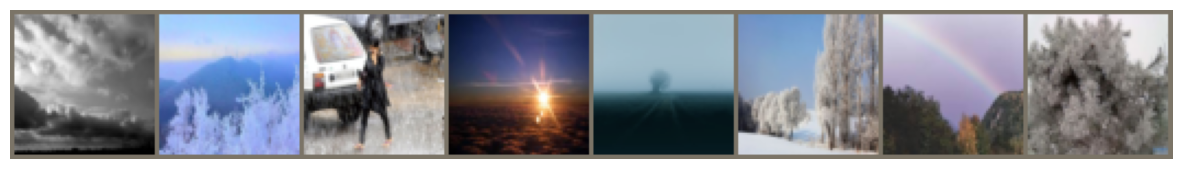

Лейблы:    cloudy   |    rime    |   rainy    |  sunrise   |   foggy    |    rime    |  rainbow   |    rime   


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(15, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

images_to_show = images[:8]
labels_to_show = labels[:8]

imshow(torchvision.utils.make_grid(images_to_show))

classes = full_dataset.classes
print('Лейблы: ', ' | '.join(f'{classes[labels_to_show[j]]:^10s}' for j in range(8)))

In [34]:
class WeatherCNN(nn.Module):
    def __init__(self):
        super(WeatherCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=32*8*8, out_features=len(full_dataset.classes))

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [35]:
model = WeatherCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [37]:

epochs = 50

for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:
        optimizer.zero_grad()
        predict = model(images)
        Loss = criterion(predict, labels)
        Loss.backward()
        optimizer.step()
    
    model.eval()

    test_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for images, labels in test_loader:
            predict = model(images)
            predicted_classes = torch.argmax(predict, dim=1)
            Loss = criterion(predict, labels)
            test_loss += Loss.item()
            correct_predictions += (predicted_classes == labels).sum().item()
            total_predictions += labels.size(0)

        avg_test_loss = test_loss/len(test_loader)

        accuracy = (correct_predictions / total_predictions) * 100

        print(f'Эпоха [{epoch+1}/{epochs}], Loss на тесте: {avg_test_loss:.4f}, Точность: {accuracy:.2f}%')



Эпоха [1/50], Loss на тесте: 1.3896, Точность: 51.92%
Эпоха [2/50], Loss на тесте: 1.3918, Точность: 49.52%
Эпоха [3/50], Loss на тесте: 1.3136, Точность: 54.49%
Эпоха [4/50], Loss на тесте: 1.2667, Точность: 55.13%
Эпоха [5/50], Loss на тесте: 1.2401, Точность: 54.65%
Эпоха [6/50], Loss на тесте: 1.1816, Точность: 57.21%
Эпоха [7/50], Loss на тесте: 1.2408, Точность: 58.81%
Эпоха [8/50], Loss на тесте: 1.1711, Точность: 59.13%
Эпоха [9/50], Loss на тесте: 1.1707, Точность: 59.29%
Эпоха [10/50], Loss на тесте: 1.2079, Точность: 57.69%
Эпоха [11/50], Loss на тесте: 1.1212, Точность: 59.29%
Эпоха [12/50], Loss на тесте: 1.0329, Точность: 65.71%
Эпоха [13/50], Loss на тесте: 1.1368, Точность: 62.34%
Эпоха [14/50], Loss на тесте: 1.0819, Точность: 62.98%
Эпоха [15/50], Loss на тесте: 1.1893, Точность: 63.94%
Эпоха [16/50], Loss на тесте: 1.2188, Точность: 60.90%
Эпоха [17/50], Loss на тесте: 1.1699, Точность: 64.74%
Эпоха [18/50], Loss на тесте: 1.1424, Точность: 62.98%
Эпоха [19/50], Loss

Добавим агументацию к тренировочному датасету и dropout в наш скрытый слой

In [ ]:
train_transforms = transforms.Compose(
    transforms.Resize(64,64),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

test_transforms = transforms.Compose(
    transforms.Resize(64,64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

train_dataset = ImageFolder(root=dataPth, transform=train_transforms)

test_dataset = ImageFolder(root=dataPth, transform=test_transforms)

train_loader = 
                